Saving placement_predict_50k_adjusted.csv to placement_predict_50k_adjusted (2).csv
Dataset Shape: (50000, 21)


,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,CGPA,AttendancePercent,Internships,...,Workshops,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,PlacementStatus,IsAnomaly
0,Female,Delhi,Tier3,IT,DataScience,Yes,Yes,6.63,68.3,2,...,0.0,1,0,62.3,6.57,40.6,65.7,No,0,0
1,Male,Chennai,Tier2,ECE,AI,Yes,No,6.40,71.0,1,...,0.0,2,0,44.0,5.86,40.3,51.8,No,0,0
2,Female,Hyderabad,Tier3,ECE,Networking,No,No,7.73,75.1,1,...,2.0,2,1,73.8,7.50,73.6,67.9,No,1,0
3,Female,Jaipur,Tier3,ECE,Embedded,No,No,9.73,99.2,4,...,5.0,6,2,100.0,9.41,98.7,NaN,No,1,0
4,Male,Ahmedabad,Tier3,Mechanical,DataScience,No,No,9.01,99.6,2,...,NaN,4,2,90.8,9.24,83.1,100.0,No,1,0



Column Names:
['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'PlacementStatus', 'IsAnomaly']

Missing Values:
Gender                   0
City                     0
CollegeTier              0
Stream                   0
Specialisation           0
Hostel                   0
HistoryOfBacklogs        0
CGPA                     0
AttendancePercent        0
Internships              0
Projects                 0
Workshops             4488
Certifications           0
Publications             0
AptitudeTestScore     4029
SoftSkillsRating      3526
CodingTestScore       2976
MockInterviewScore    4957
ExtraCurricular          0
PlacementStatus          0
IsAnomaly                0
dtype: int64

Target Distribution:
PlacementStatus
0    26251
1    23749

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.7896,0.7823,0.7718,0.7770
1,LightGBM,0.7891,0.7808,0.7731,0.7769


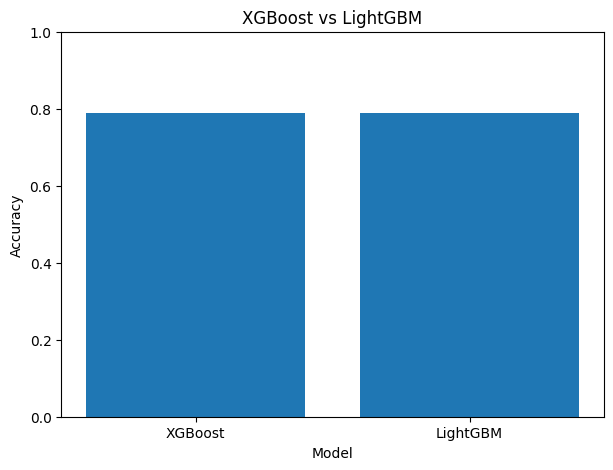

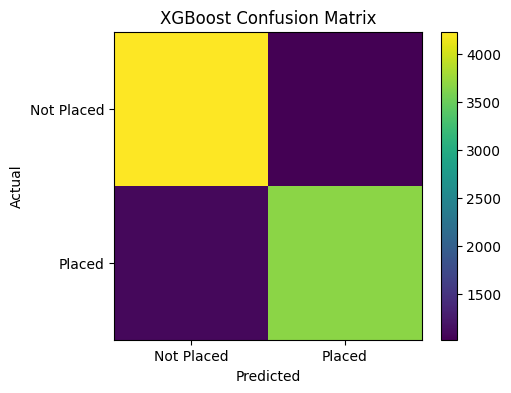

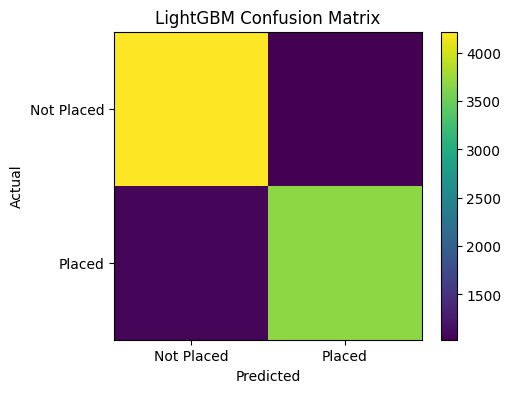


Calculating SHAP values...


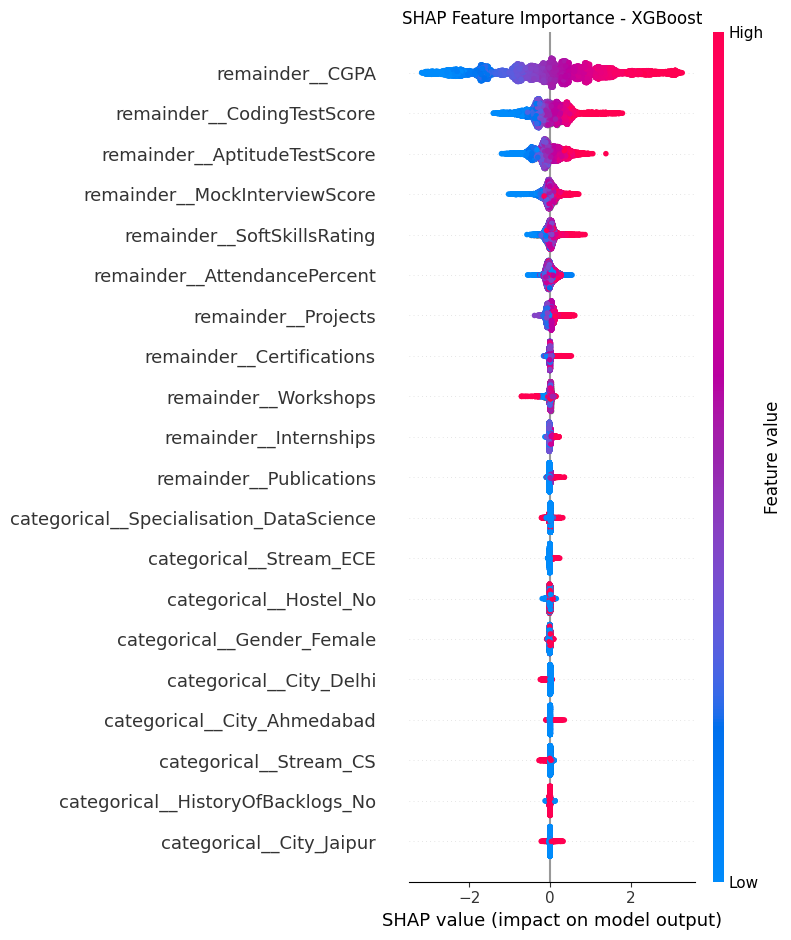

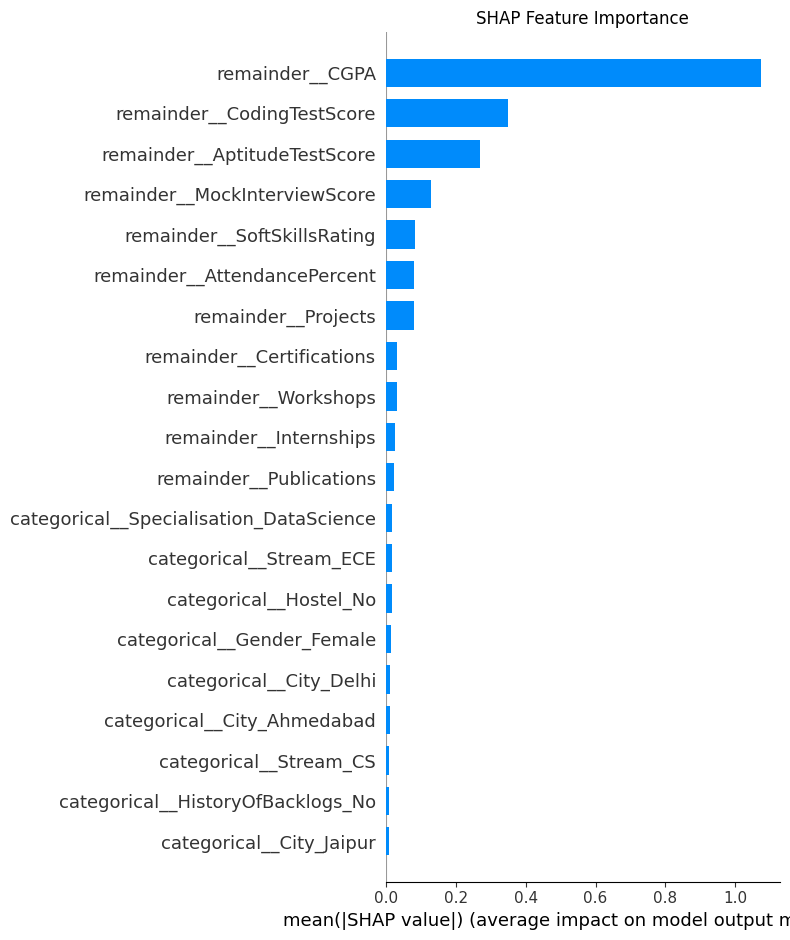


Top 15 Important Features:


,Feature,Importance
30,remainder__CGPA,0.268574
39,remainder__CodingTestScore,0.130473
37,remainder__AptitudeTestScore,0.109188
38,remainder__SoftSkillsRating,0.029884
40,remainder__MockInterviewScore,0.026670
31,remainder__AttendancePercent,0.024619
33,remainder__Projects,0.017901
27,categorical__HistoryOfBacklogs_Yes,0.016233
35,remainder__Certifications,0.016174
36,remainder__Publications,0.015040



FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.7896,0.7823,0.7718,0.7770
1,LightGBM,0.7891,0.7808,0.7731,0.7769



Experiment 8 Completed Successfully!


In [2]:
# ============================================================
# EXPERIMENT 8
# XGBoost, LightGBM and SHAP - PlacementPredict
# ============================================================

# STEP 1: Install required libraries
!pip install -q xgboost lightgbm shap

# STEP 2: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap

# ============================================================
# STEP 3: Upload Dataset
# ============================================================

uploaded = files.upload()

# Read your uploaded CSV
df = pd.read_csv("placement_predict_50k_adjusted.csv")

print("Dataset Shape:", df.shape)
display(df.head())

# ============================================================
# STEP 4: Basic Dataset Information
# ============================================================

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution:")
print(df["PlacementStatus"].value_counts())

# ============================================================
# STEP 5: Remove unnecessary column
# ============================================================

# IsAnomaly is not used as a prediction feature
X = df.drop(columns=["PlacementStatus", "IsAnomaly"])

y = df["PlacementStatus"]

print("\nFeatures:", X.shape)
print("Target:", y.shape)

# ============================================================
# STEP 6: Identify categorical and numerical columns
# ============================================================

categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_cols = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("\nCategorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

# ============================================================
# STEP 7: Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)

# ============================================================
# STEP 8: One-Hot Encoding
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("\nEncoded Training Shape:",
      X_train_encoded.shape)

print("Encoded Testing Shape:",
      X_test_encoded.shape)

# ============================================================
# STEP 9: Get Feature Names
# ============================================================

feature_names = preprocessor.get_feature_names_out()

print("\nNumber of Features:",
      len(feature_names))

# ============================================================
# STEP 10: XGBoost Model
# ============================================================

xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

print("\nTraining XGBoost...")

xgb_model.fit(
    X_train_encoded,
    y_train
)

# Prediction
xgb_pred = xgb_model.predict(
    X_test_encoded
)

# ============================================================
# STEP 11: Evaluate XGBoost
# ============================================================

xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

xgb_precision = precision_score(
    y_test,
    xgb_pred
)

xgb_recall = recall_score(
    y_test,
    xgb_pred
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred
)

print("\n========== XGBoost Results ==========")

print("Accuracy :", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall   :", round(xgb_recall, 4))
print("F1 Score :", round(xgb_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

# ============================================================
# STEP 12: LightGBM Model
# ============================================================

lgbm_model = LGBMClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

print("\nTraining LightGBM...")

lgbm_model.fit(
    X_train_encoded,
    y_train
)

# Prediction
lgbm_pred = lgbm_model.predict(
    X_test_encoded
)

# ============================================================
# STEP 13: Evaluate LightGBM
# ============================================================

lgbm_accuracy = accuracy_score(
    y_test,
    lgbm_pred
)

lgbm_precision = precision_score(
    y_test,
    lgbm_pred
)

lgbm_recall = recall_score(
    y_test,
    lgbm_pred
)

lgbm_f1 = f1_score(
    y_test,
    lgbm_pred
)

print("\n========== LightGBM Results ==========")

print("Accuracy :", round(lgbm_accuracy, 4))
print("Precision:", round(lgbm_precision, 4))
print("Recall   :", round(lgbm_recall, 4))
print("F1 Score :", round(lgbm_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        lgbm_pred
    )
)

# ============================================================
# STEP 14: Compare XGBoost and LightGBM
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "XGBoost",
        "LightGBM"
    ],

    "Accuracy": [
        xgb_accuracy,
        lgbm_accuracy
    ],

    "Precision": [
        xgb_precision,
        lgbm_precision
    ],

    "Recall": [
        xgb_recall,
        lgbm_recall
    ],

    "F1 Score": [
        xgb_f1,
        lgbm_f1
    ]
})

print("\n========== Model Comparison ==========")

display(comparison.round(4))

# ============================================================
# STEP 15: Accuracy Comparison Graph
# ============================================================

plt.figure(figsize=(7,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("XGBoost vs LightGBM")

plt.ylim(0, 1)

plt.show()

# ============================================================
# STEP 16: Confusion Matrix - XGBoost
# ============================================================

cm_xgb = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(5,4))

plt.imshow(cm_xgb)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.xticks(
    [0, 1],
    ["Not Placed", "Placed"]
)

plt.yticks(
    [0, 1],
    ["Not Placed", "Placed"]
)

plt.show()

# ============================================================
# STEP 17: Confusion Matrix - LightGBM
# ============================================================

cm_lgbm = confusion_matrix(
    y_test,
    lgbm_pred
)

plt.figure(figsize=(5,4))

plt.imshow(cm_lgbm)

plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.xticks(
    [0, 1],
    ["Not Placed", "Placed"]
)

plt.yticks(
    [0, 1],
    ["Not Placed", "Placed"]
)

plt.show()

# ============================================================
# STEP 18: SHAP Analysis - XGBoost
# ============================================================
print("\nCalculating SHAP values...")

# X_test_encoded is already a dense numpy array
X_test_dense = X_test_encoded

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_dense)


# ============================================================
# STEP 19: SHAP Summary Plot
# ============================================================

plt.figure()

shap.summary_plot(
    shap_values,
    X_test_dense,
    feature_names=feature_names,
    show=False
)

plt.title(
    "SHAP Feature Importance - XGBoost"
)

plt.tight_layout()
plt.show()

# ============================================================
# STEP 20: SHAP Bar Plot
# ============================================================

plt.figure()

shap.summary_plot(
    shap_values,
    X_test_dense,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.title(
    "SHAP Feature Importance"
)

plt.tight_layout()
plt.show()

# ============================================================
# STEP 21: XGBoost Feature Importance
# ============================================================

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 15 Important Features:")

display(
    importance.head(15)
)

# ============================================================
# STEP 22: Final Result
# ============================================================

print("\n====================================")
print("FINAL MODEL COMPARISON")
print("====================================")

display(
    comparison.round(4)
)

print("\nExperiment 8 Completed Successfully!")